In [3]:
import pandas as pd
import numpy as np
import mysql.connector
from mysql.connector import Error
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройки для отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

# Параметры подключения
DB_CONFIG = {
    'host': '95.131.149.21',
    'port': 3306,
    'database': 'mgpu_ico_etl_05',
    'user': 'mgpu_ico_etl_05',  # Введите ваш логин
    'password': ''  # Введите ваш пароль
}

def connect_to_mysql():
    """Подключение к MySQL"""
    try:
        connection = mysql.connector.connect(**DB_CONFIG)
        if connection.is_connected():
            print("Успешное подключение к MySQL")
            return connection
    except Error as e:
        print(f"Ошибка подключения: {e}")
        return None

def load_data():
    """Загрузка данных из всех таблиц"""
    connection = connect_to_mysql()
    if not connection:
        return None, None, None

    try:
        # Загрузка заказов
        orders_query = "SELECT * FROM orders"
        orders_df = pd.read_sql(orders_query, connection)

        # Загрузка клиентов
        customers_query = "SELECT * FROM customers"
        customers_df = pd.read_sql(customers_query, connection)

        # Загрузка продуктов
        products_query = "SELECT * FROM products"
        products_df = pd.read_sql(products_query, connection)

        print(f"Загружено заказов: {len(orders_df)}")
        print(f"Загружено клиентов: {len(customers_df)}")
        print(f"Загружено продуктов: {len(products_df)}")

        return orders_df, customers_df, products_df

    except Error as e:
        print(f"Ошибка при загрузке данных: {e}")
        return None, None, None
    finally:
        if connection.is_connected():
            connection.close()
            print("Соединение закрыто")

In [2]:
!pip install mysql-connector-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 22.0 MB/s eta 0:00:00


In [4]:
def regional_analysis(orders_df, customers_df):
    """Анализ по регионам"""

    # Объединение данных заказов с клиентами
    merged_df = pd.merge(orders_df, customers_df, left_on='row_id', right_on='id', how='left')

    # 1. Основные показатели по регионам
    regional_stats = merged_df.groupby('region').agg({
        'sales': ['sum', 'mean', 'count'],
        'profit': ['sum', 'mean'],
        'quantity': 'sum',
        'discount': 'mean',
        'returned': 'sum'
    }).round(2)

    regional_stats.columns = ['Сумма продаж', 'Средний чек', 'Кол-во заказов',
                              'Сумма прибыли', 'Средняя прибыль', 'Всего товаров',
                              'Средняя скидка', 'Кол-во возвратов']
    regional_stats = regional_stats.reset_index()

    # 2. Рентабельность по регионам
    regional_stats['Рентабельность (%)'] = (regional_stats['Сумма прибыли'] / regional_stats['Сумма продаж'] * 100).round(2)
    regional_stats['Доля возвратов (%)'] = (regional_stats['Кол-во возвратов'] / regional_stats['Кол-во заказов'] * 100).round(2)

    # 3. Топ городов по прибыли
    top_cities = merged_df.groupby('city').agg({
        'profit': 'sum',
        'sales': 'sum',
        'row_id': 'count'
    }).round(2)
    top_cities.columns = ['Прибыль', 'Продажи', 'Кол-во заказов']
    top_cities = top_cities.sort_values('Прибыль', ascending=False).head(10)

    return regional_stats, top_cities, merged_df

def visualize_regional_analysis(regional_stats, merged_df):
    """Визуализация регионального анализа"""

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Региональный анализ продаж', fontsize=16, fontweight='bold')

    # 1. Продажи и прибыль по регионам
    ax1 = axes[0, 0]
    x = np.arange(len(regional_stats['region']))
    width = 0.35

    bars1 = ax1.bar(x - width/2, regional_stats['Сумма продаж'], width, label='Продажи', color='skyblue')
    bars2 = ax1.bar(x + width/2, regional_stats['Сумма прибыли'], width, label='Прибыль', color='lightgreen')

    ax1.set_xlabel('Регион')
    ax1.set_ylabel('Сумма')
    ax1.set_title('Продажи и прибыль по регионам')
    ax1.set_xticks(x)
    ax1.set_xticklabels(regional_stats['region'], rotation=45)
    ax1.legend()

    # Добавление значений на столбцы
    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:,.0f}', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:,.0f}', ha='center', va='bottom', fontsize=8)

    # 2. Рентабельность по регионам
    ax2 = axes[0, 1]
    colors = ['green' if x > 0 else 'red' for x in regional_stats['Рентабельность (%)']]
    bars = ax2.bar(regional_stats['region'], regional_stats['Рентабельность (%)'], color=colors)
    ax2.set_xlabel('Регион')
    ax2.set_ylabel('Рентабельность (%)')
    ax2.set_title('Рентабельность по регионам')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    plt.setp(ax2.get_xticklabels(), rotation=45)

    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

    # 3. Количество заказов по регионам
    ax3 = axes[1, 0]
    ax3.pie(regional_stats['Кол-во заказов'], labels=regional_stats['region'], autopct='%1.1f%%', startangle=90)
    ax3.set_title('Распределение заказов по регионам')

    # 4. Доля возвратов по регионам
    ax4 = axes[1, 1]
    bars = ax4.bar(regional_stats['region'], regional_stats['Доля возвратов (%)'], color='salmon')
    ax4.set_xlabel('Регион')
    ax4.set_ylabel('Доля возвратов (%)')
    ax4.set_title('Доля возвратов по регионам')
    plt.setp(ax4.get_xticklabels(), rotation=45)

    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

In [5]:
def profitability_analysis(orders_df, customers_df, products_df):
    """Анализ прибыльности"""

    # Объединение всех данных
    merged_df = pd.merge(orders_df, customers_df, left_on='row_id', right_on='id', how='left')
    merged_df = pd.merge(merged_df, products_df, left_on='row_id', right_on='id', how='left', suffixes=('_cust', '_prod'))

    # 1. Общие показатели прибыльности
    total_sales = orders_df['sales'].sum()
    total_profit = orders_df['profit'].sum()
    total_orders = len(orders_df)
    avg_profit_margin = (total_profit / total_sales * 100) if total_sales > 0 else 0

    print("=== ОБЩИЕ ПОКАЗАТЕЛИ ПРИБЫЛЬНОСТИ ===")
    print(f"Общий объем продаж: {total_sales:,.2f}")
    print(f"Общая прибыль: {total_profit:,.2f}")
    print(f"Средняя маржинальность: {avg_profit_margin:.2f}%")
    print(f"Количество заказов: {total_orders}")
    print(f"Средняя прибыль на заказ: {total_profit/total_orders:,.2f}\n")

    # 2. Прибыльность по категориям продуктов
    category_profit = merged_df.groupby('category').agg({
        'profit': ['sum', 'mean'],
        'sales': 'sum',
        'row_id': 'count'
    }).round(2)
    category_profit.columns = ['Общая прибыль', 'Средняя прибыль', 'Продажи', 'Кол-во заказов']
    category_profit = category_profit.reset_index()
    category_profit['Маржинальность (%)'] = (category_profit['Общая прибыль'] / category_profit['Продажи'] * 100).round(2)

    print("=== ПРИБЫЛЬНОСТЬ ПО КАТЕГОРИЯМ ===")
    print(category_profit.to_string(index=False))
    print()

    # 3. Прибыльность по сегментам клиентов
    segment_profit = merged_df.groupby('segment').agg({
        'profit': ['sum', 'mean'],
        'sales': 'sum',
        'row_id': 'count'
    }).round(2)
    segment_profit.columns = ['Общая прибыль', 'Средняя прибыль', 'Продажи', 'Кол-во заказов']
    segment_profit = segment_profit.reset_index()
    segment_profit['Маржинальность (%)'] = (segment_profit['Общая прибыль'] / segment_profit['Продажи'] * 100).round(2)

    print("=== ПРИБЫЛЬНОСТЬ ПО СЕГМЕНТАМ КЛИЕНТОВ ===")
    print(segment_profit.to_string(index=False))
    print()

    # 4. Топ-10 самых прибыльных продуктов
    top_products = merged_df.groupby(['category', 'sub_category', 'product_name']).agg({
        'profit': 'sum',
        'sales': 'sum',
        'row_id': 'count'
    }).round(2)
    top_products.columns = ['Прибыль', 'Продажи', 'Кол-во заказов']
    top_products = top_products.sort_values('Прибыль', ascending=False).head(10)

    print("=== ТОП-10 САМЫХ ПРИБЫЛЬНЫХ ПРОДУКТОВ ===")
    print(top_products.to_string())
    print()

    # 5. Анализ убыточных продуктов
    loss_products = merged_df[merged_df['profit'] < 0].groupby(['category', 'sub_category']).agg({
        'profit': 'sum',
        'row_id': 'count'
    }).round(2)
    loss_products.columns = ['Убыток', 'Кол-во заказов']
    loss_products = loss_products.sort_values('Убыток')

    print("=== УБЫТОЧНЫЕ КАТЕГОРИИ ПРОДУКТОВ ===")
    print(loss_products.to_string())
    print()

    # 6. Влияние скидок на прибыльность
    discount_analysis = merged_df.groupby(pd.cut(merged_df['discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1])).agg({
        'profit': 'sum',
        'sales': 'sum',
        'row_id': 'count'
    }).round(2)
    discount_analysis.columns = ['Прибыль', 'Продажи', 'Кол-во заказов']
    discount_analysis.index.name = 'Диапазон скидок'

    print("=== АНАЛИЗ ВЛИЯНИЯ СКИДОК ===")
    print(discount_analysis.to_string())

    return merged_df, category_profit, segment_profit

def visualize_profitability_analysis(merged_df, category_profit, segment_profit):
    """Визуализация анализа прибыльности"""

    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Анализ прибыльности', fontsize=16, fontweight='bold')

    # 1. Прибыль по категориям
    ax1 = axes[0, 0]
    bars = ax1.bar(category_profit['category'], category_profit['Общая прибыль'], color='lightgreen')
    ax1.set_xlabel('Категория')
    ax1.set_ylabel('Прибыль')
    ax1.set_title('Прибыль по категориям продуктов')
    plt.setp(ax1.get_xticklabels(), rotation=45)

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height, f'{height:,.0f}', ha='center', va='bottom')

    # 2. Маржинальность по категориям
    ax2 = axes[0, 1]
    colors = ['green' if x > 0 else 'red' for x in category_profit['Маржинальность (%)']]
    bars = ax2.bar(category_profit['category'], category_profit['Маржинальность (%)'], color=colors)
    ax2.set_xlabel('Категория')
    ax2.set_ylabel('Маржинальность (%)')
    ax2.set_title('Маржинальность по категориям')
    plt.setp(ax2.get_xticklabels(), rotation=45)
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}%', ha='center', va='bottom' if height > 0 else 'top')

    # 3. Прибыль по сегментам клиентов
    ax3 = axes[0, 2]
    bars = ax3.bar(segment_profit['segment'], segment_profit['Общая прибыль'], color='lightblue')
    ax3.set_xlabel('Сегмент')
    ax3.set_ylabel('Прибыль')
    ax3.set_title('Прибыль по сегментам клиентов')
    plt.setp(ax3.get_xticklabels(), rotation=45)

    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height, f'{height:,.0f}', ha='center', va='bottom')

    # 4. Влияние скидок на прибыль
    ax4 = axes[1, 0]
    discount_groups = merged_df.groupby(pd.cut(merged_df['discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1]))['profit'].mean()
    discount_groups.plot(kind='bar', ax=ax4, color='orange')
    ax4.set_xlabel('Диапазон скидок')
    ax4.set_ylabel('Средняя прибыль')
    ax4.set_title('Влияние скидок на среднюю прибыль')
    plt.setp(ax4.get_xticklabels(), rotation=45)

    # 5. Корреляция между продажами и прибылью
    ax5 = axes[1, 1]
    scatter = ax5.scatter(merged_df['sales'], merged_df['profit'],
                         c=merged_df['discount'], cmap='RdYlGn', alpha=0.6)
    ax5.set_xlabel('Продажи')
    ax5.set_ylabel('Прибыль')
    ax5.set_title('Корреляция продаж и прибыли')
    plt.colorbar(scatter, ax=ax5, label='Скидка')

    # 6. Распределение прибыли
    ax6 = axes[1, 2]
    merged_df['profit'].hist(bins=50, ax=ax6, color='skyblue', edgecolor='black')
    ax6.set_xlabel('Прибыль')
    ax6.set_ylabel('Частота')
    ax6.set_title('Распределение прибыли по заказам')
    ax6.axvline(x=0, color='red', linestyle='--', linewidth=1)

    plt.tight_layout()
    plt.show()

In [6]:
def additional_analysis(merged_df):
    """Дополнительный анализ"""

    # 1. Анализ временных рядов (по месяцам)
    merged_df['order_date'] = pd.to_datetime(merged_df['order_date'])
    merged_df['year_month'] = merged_df['order_date'].dt.to_period('M')

    monthly_analysis = merged_df.groupby('year_month').agg({
        'sales': 'sum',
        'profit': 'sum',
        'row_id': 'count'
    }).round(2)
    monthly_analysis.columns = ['Продажи', 'Прибыль', 'Кол-во заказов']

    print("=== ПОМЕСЯЧНЫЙ АНАЛИЗ ===")
    print(monthly_analysis.head(10).to_string())
    print()

    # 2. Анализ по способам доставки
    ship_analysis = merged_df.groupby('ship_mode').agg({
        'profit': 'sum',
        'sales': 'sum',
        'row_id': 'count'
    }).round(2)
    ship_analysis.columns = ['Прибыль', 'Продажи', 'Кол-во заказов']
    ship_analysis['Маржинальность (%)'] = (ship_analysis['Прибыль'] / ship_analysis['Продажи'] * 100).round(2)

    print("=== АНАЛИЗ ПО СПОСОБАМ ДОСТАВКИ ===")
    print(ship_analysis.to_string())

    return monthly_analysis, ship_analysis

def export_results(regional_stats, category_profit, segment_profit, monthly_analysis):
    """Экспорт результатов в Excel"""

    with pd.ExcelWriter('analysis_results.xlsx', engine='openpyxl') as writer:
        regional_stats.to_excel(writer, sheet_name='Региональный анализ', index=False)
        category_profit.to_excel(writer, sheet_name='Прибыль по категориям', index=False)
        segment_profit.to_excel(writer, sheet_name='Прибыль по сегментам', index=False)
        monthly_analysis.to_excel(writer, sheet_name='Помесячный анализ')

    print("Результаты экспортированы в файл 'analysis_results.xlsx'")

АНАЛИЗ ДАННЫХ: РЕГИОНЫ И ПРИБЫЛЬНОСТЬ
Успешное подключение к MySQL
Загружено заказов: 4284
Загружено клиентов: 4910
Загружено продуктов: 5371
Соединение закрыто

РЕГИОНАЛЬНЫЙ АНАЛИЗ

Статистика по регионам:
 region  Сумма продаж  Средний чек  Кол-во заказов  Сумма прибыли  Средняя прибыль  Всего товаров  Средняя скидка  Кол-во возвратов  Рентабельность (%)  Доля возвратов (%)
Central     217470.57       438.45             496       30493.71            61.48           2847            0.15             39.00               14.02                7.86
   East     184598.33       312.35             591       12909.63            21.84           3447            0.17             61.00                6.99               10.32
  South     103550.94       295.86             350       14839.21            42.40           1988            0.16             19.00               14.33                5.43
   West     205759.29       318.02             647       24389.87            37.70           3863        

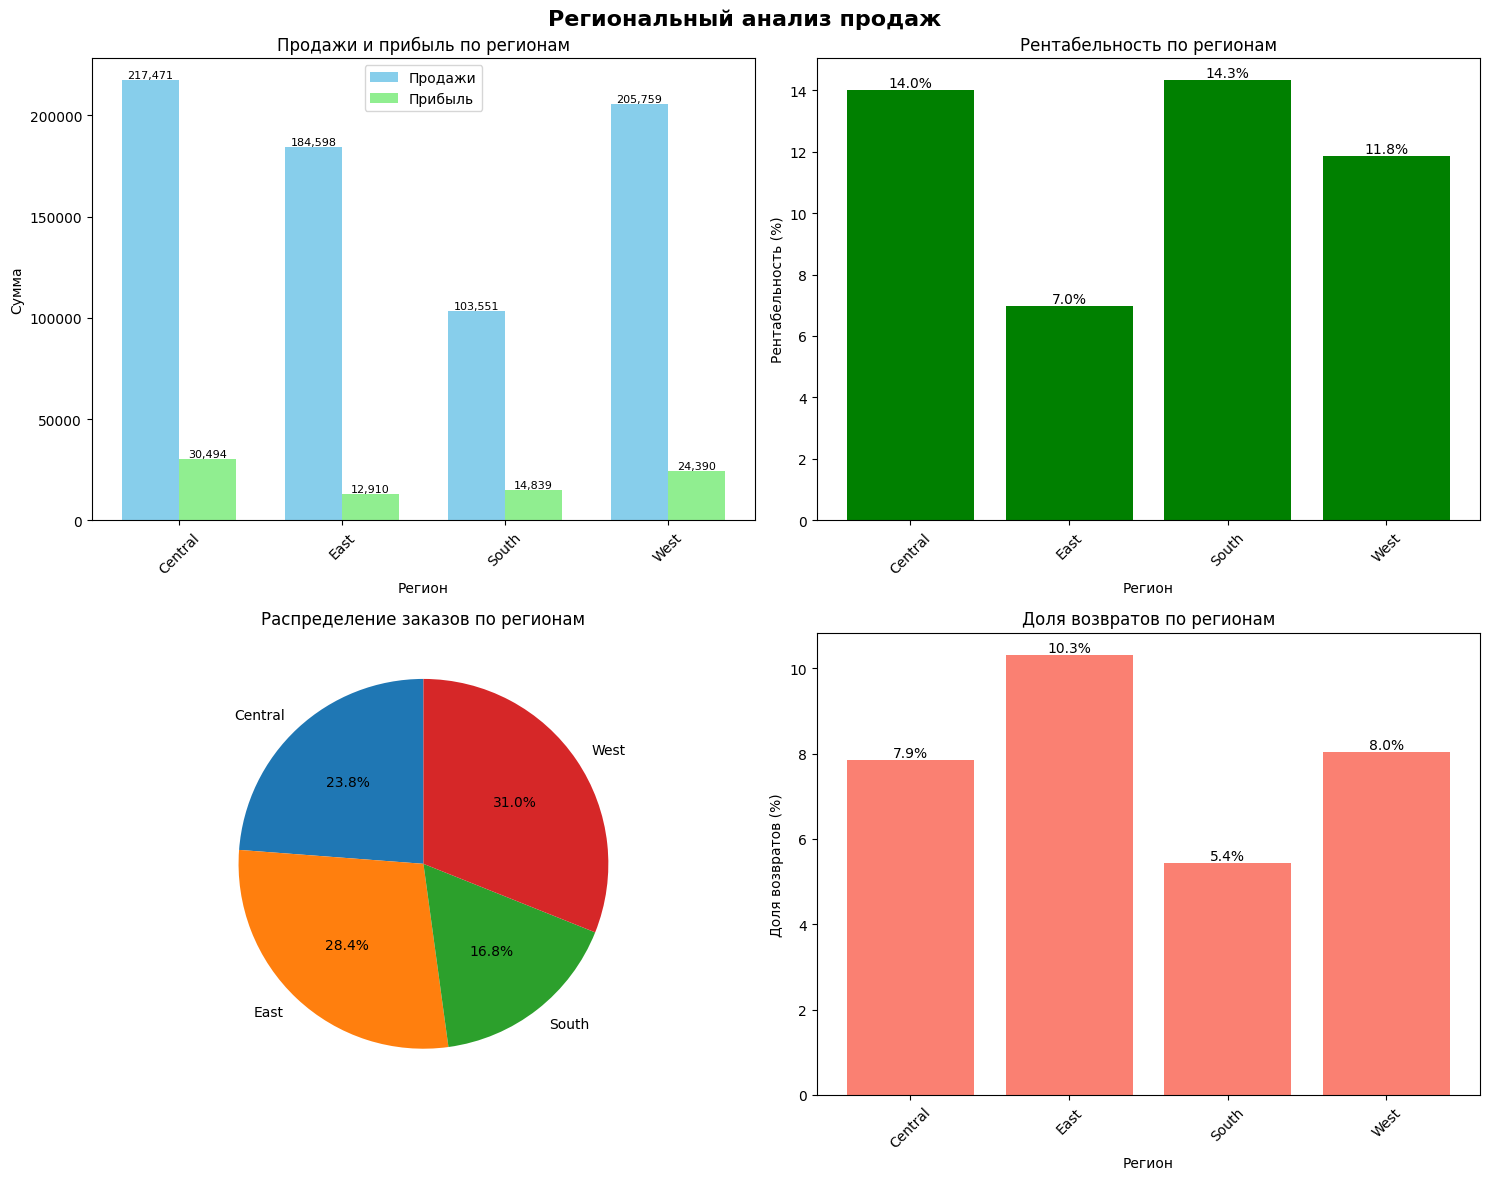

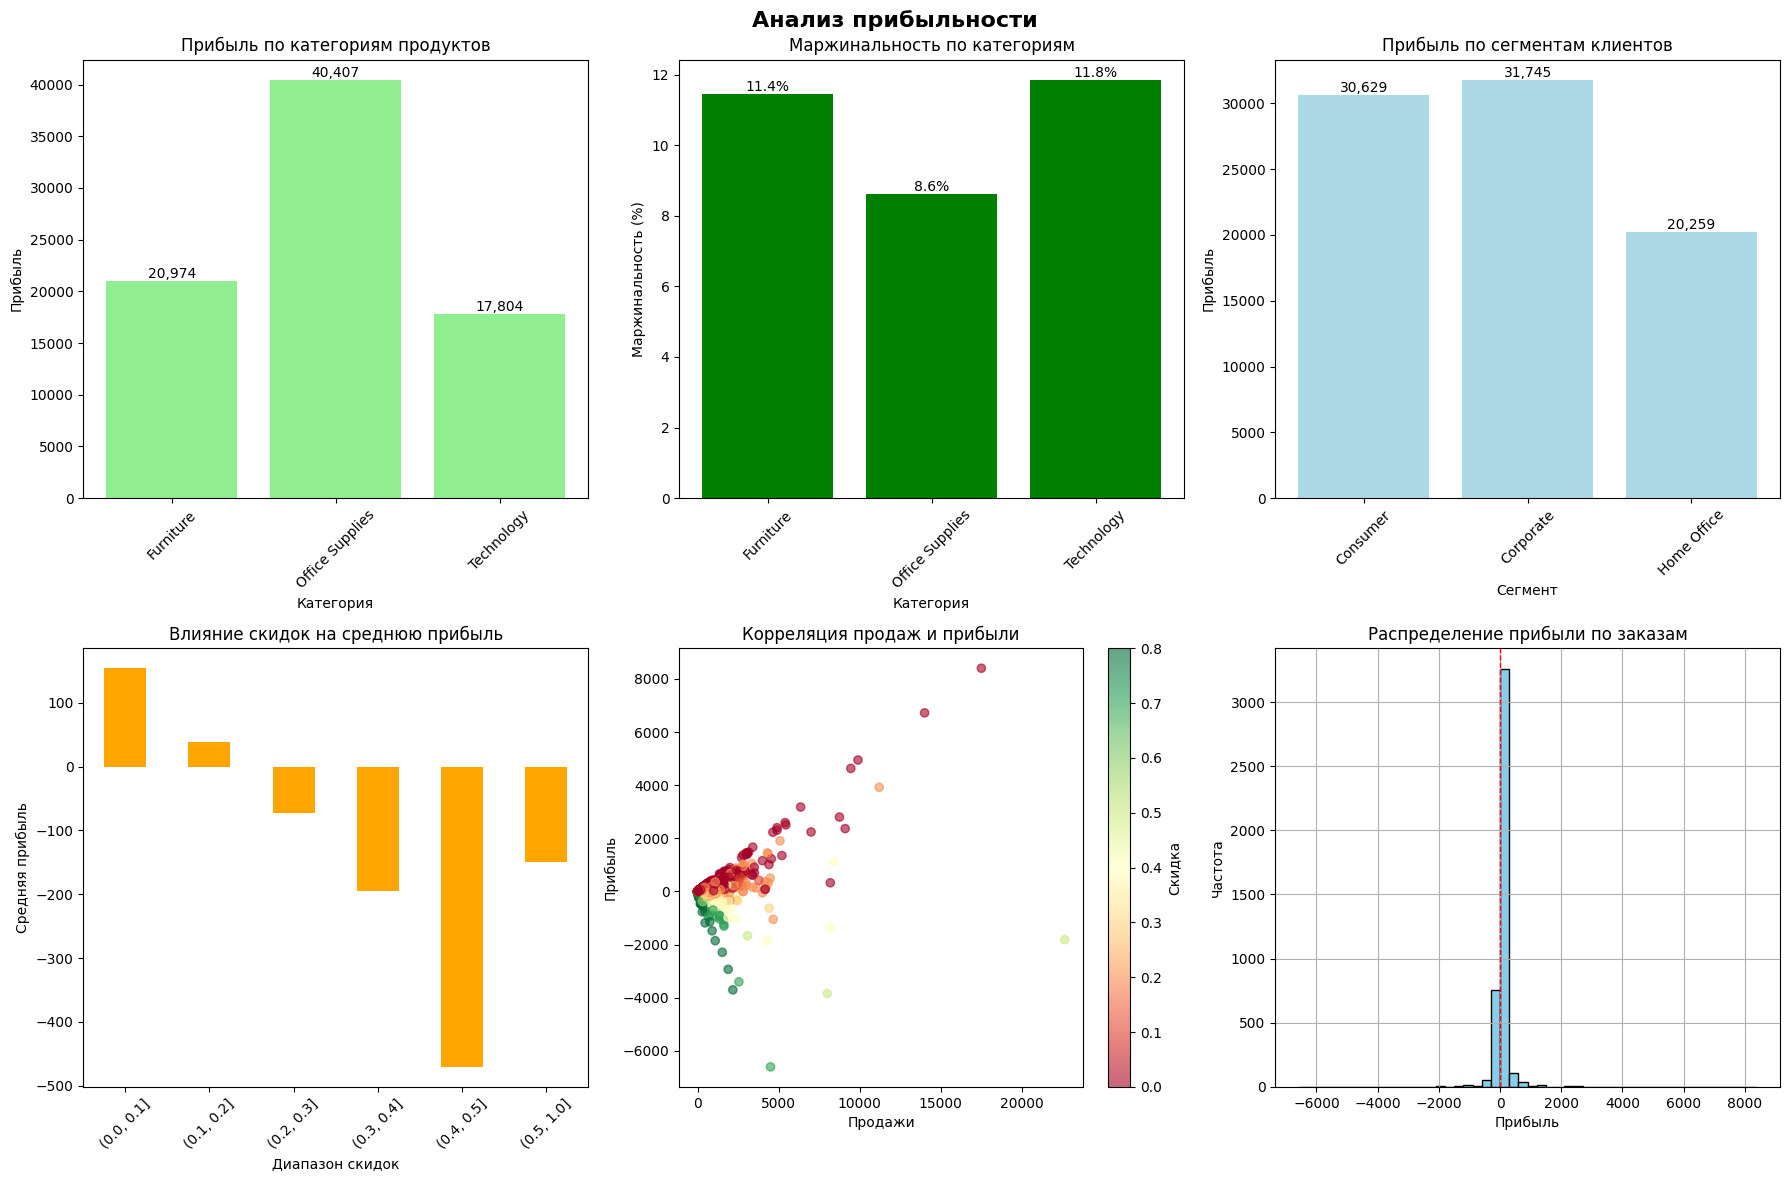

Результаты экспортированы в файл 'analysis_results.xlsx'


In [7]:
def main():
    """Главная функция для запуска анализа"""

    print("="*60)
    print("АНАЛИЗ ДАННЫХ: РЕГИОНЫ И ПРИБЫЛЬНОСТЬ")
    print("="*60)

    # Загрузка данных
    orders_df, customers_df, products_df = load_data()

    if orders_df is not None and customers_df is not None and products_df is not None:

        # Региональный анализ
        print("\n" + "="*60)
        print("РЕГИОНАЛЬНЫЙ АНАЛИЗ")
        print("="*60)
        regional_stats, top_cities, merged_df = regional_analysis(orders_df, customers_df)

        print("\nСтатистика по регионам:")
        print(regional_stats.to_string(index=False))

        print("\nТоп-10 городов по прибыли:")
        print(top_cities.to_string())

        # Анализ прибыльности
        print("\n" + "="*60)
        print("АНАЛИЗ ПРИБЫЛЬНОСТИ")
        print("="*60)
        merged_df_full, category_profit, segment_profit = profitability_analysis(orders_df, customers_df, products_df)

        # Дополнительный анализ
        monthly_analysis, ship_analysis = additional_analysis(merged_df_full)

        # Визуализация
        visualize_regional_analysis(regional_stats, merged_df)
        visualize_profitability_analysis(merged_df_full, category_profit, segment_profit)

        # Экспорт результатов
        export_results(regional_stats, category_profit, segment_profit, monthly_analysis)

    else:
        print("Ошибка загрузки данных. Проверьте подключение к базе данных.")

if __name__ == "__main__":
    main()